In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm
from utils import *

### var est  for mean

In [2]:
# Parameters
sim_n = 2000 
n = 200      
B = 2000
seed = 42

# Arrays to store results
var_jackknife_sim = np.zeros(sim_n)
var_boot_sim = np.zeros(sim_n)

# Simulation
with ProcessPoolExecutor() as executor:
    futures = [
        executor.submit(simulate_mean, 
                        i=i, 
                        n=n, 
                        B=B, 
                        seed=seed)
        for i in range(sim_n)
    ]
    
    for i, future in enumerate(tqdm(futures, desc="Simulations", unit="simulation")):
        var_jackknife_sim[i], var_boot_sim[i] = future.result()

Simulations: 100%|██████████| 2000/2000 [00:16<00:00, 124.00simulation/s]


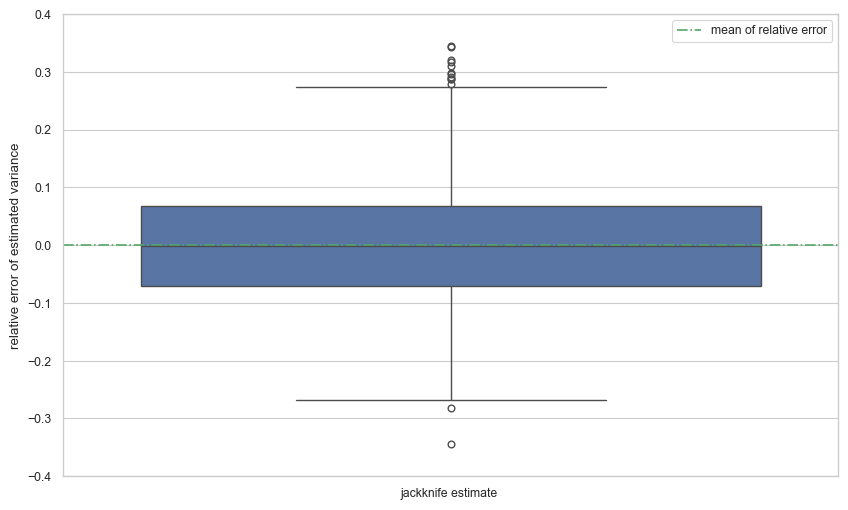

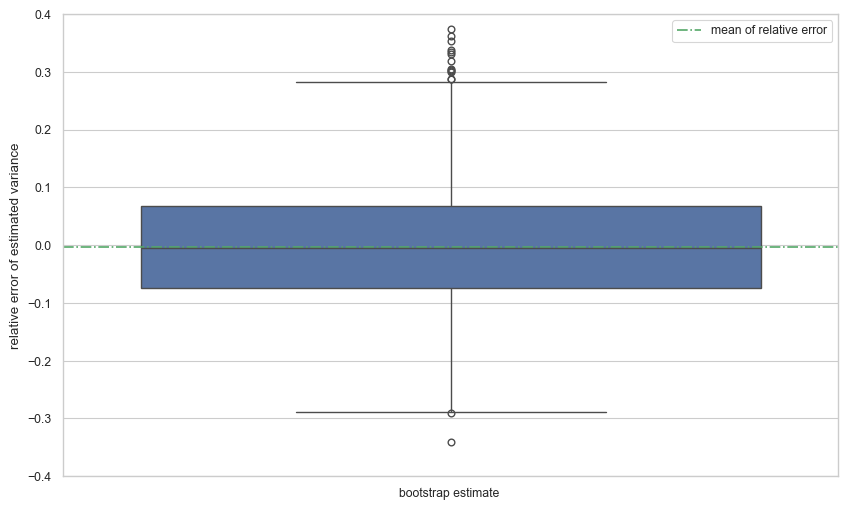

In [3]:
# plot jackkknife
df = pd.DataFrame({'jackknife estimate ': var_jackknife_sim})
plt.figure(figsize=(10, 6))
sns.set_theme(context='paper',style="whitegrid") 
sns.boxplot(data=(df-1/n)/(1/n)) 
plt.axhline(y=np.mean((df-1/n)/(1/n)), color='g', linestyle='dashdot', label='mean of relative error')  
plt.ylabel('relative error of estimated variance')
plt.legend()
plt.ylim(-0.4, 0.4)
plt.savefig("boxplot_JK_linear_mean.png", dpi = 1000)
plt.show()

# plot bootstrap
df = pd.DataFrame({'bootstrap estimate ': var_boot_sim})
plt.figure(figsize=(10, 6))
sns.set_theme(context='paper',style="whitegrid") 
sns.boxplot(data=(df-1/n)/(1/n)) 
plt.axhline(y=np.mean((df-1/n)/(1/n)), color='g', linestyle='dashdot', label='mean of relative error')  
plt.ylabel('relative error of estimated variance')
plt.legend()
plt.ylim(-0.4, 0.4)
plt.savefig("boxplot_boot_linear_mean.png", dpi = 1000)
plt.show()

### var est for pearson correlation coefficient

In [4]:
# Parameters
mean = [0, 0]
p = 0.7
cov = [[1, p], [p, 1]]

sim_n = 2_000
n = 200
B = 2000
seed = 42

var_jackknife = np.zeros(sim_n)
var_boot = np.zeros(sim_n)

# Simulation
with ProcessPoolExecutor() as executor:
    futures = [
        executor.submit(simulate_pearson, 
                        mean=mean, 
                        cov=cov, 
                        n=n, 
                        B=B, 
                        sim_i=i, 
                        seed=seed)
        for i in range(sim_n)
    ]
    
    for i, future in enumerate(tqdm(futures, desc="Simulations", unit="simulation")):
        var_jackknife[i], var_boot[i] = future.result()

# True std for the correlation https://www.jstor.org/stable/pdf/2277400.pdf?refreqid=fastly-default%3Aef46e66363b4ca95a1a81b2e1b6d92f0&ab_segments=&origin=&initiator=&acceptTC=1
true_var_corr = ((1 - p**2) / np.sqrt(n)) ** 2

Simulations: 100%|██████████| 2000/2000 [01:13<00:00, 27.39simulation/s]


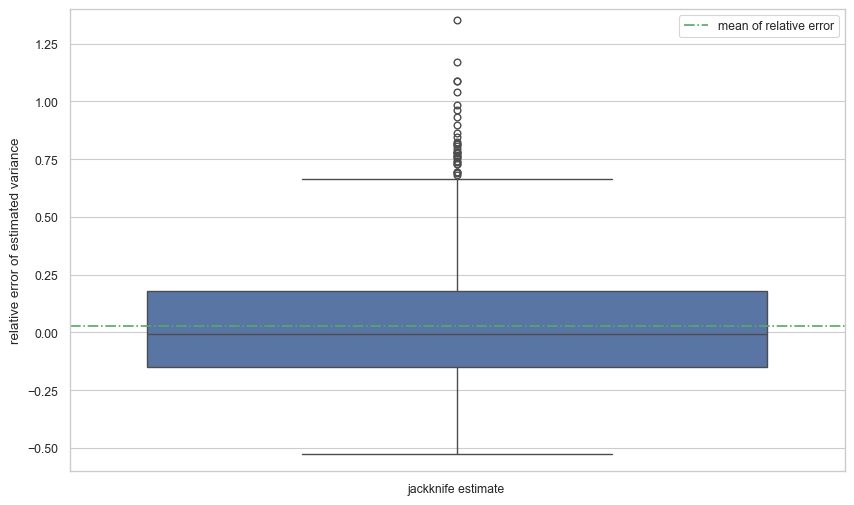

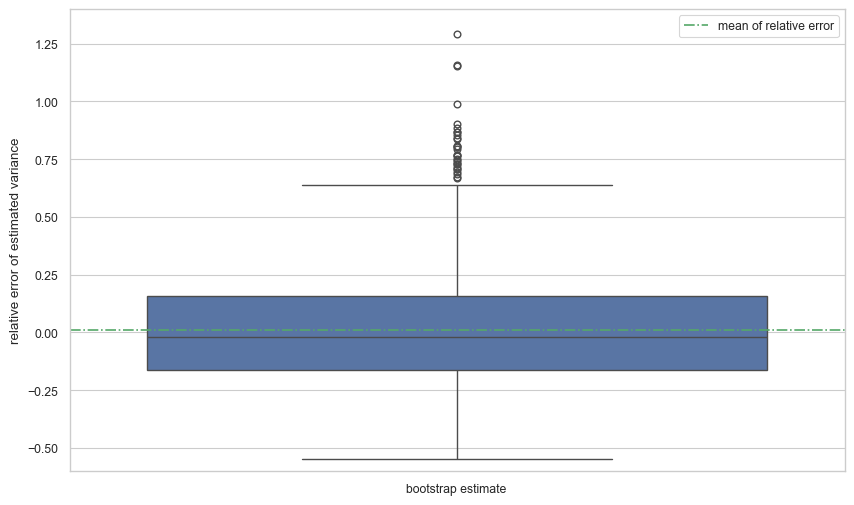

In [5]:
# plot jackknife
df = pd.DataFrame({'jackknife estimate ': var_jackknife})
plt.figure(figsize=(10, 6))
sns.set_theme(context='paper',style="whitegrid") 
sns.boxplot(data=(df-true_var_corr)/true_var_corr) 
plt.axhline(y=np.mean((df-true_var_corr)/true_var_corr), color='g', linestyle='dashdot', label='mean of relative error')  
plt.ylabel('relative error of estimated variance')
plt.legend()
plt.ylim(-0.6, 1.4)
plt.savefig("boxplot_jk_non_linear_corr.png", dpi = 1000)
plt.show()

# plot bootstrap
df2 = pd.DataFrame({'bootstrap estimate ': var_boot})
plt.figure(figsize=(10, 6))
sns.set_theme(context='paper',style="whitegrid") 
sns.boxplot(data=(df2-true_var_corr)/true_var_corr) 
plt.axhline(y=np.mean((df2-true_var_corr)/true_var_corr), color='g', linestyle='dashdot', label='mean of relative error')  
plt.ylabel('relative error of estimated variance')
plt.legend()
plt.ylim(-0.6, 1.4)
plt.savefig("boxplot_boot_non_linear_corr.png", dpi = 1000)
plt.show()

### var est of median

In [6]:
# Parameters
sim_n = 2_000
n = 200
B = 2000
seed = 42

var_jackknife = np.zeros(sim_n)
var_boot = np.zeros(sim_n)
var_emp = np.zeros(sim_n)

# Simulation
with ProcessPoolExecutor() as executor:
    futures = [
        executor.submit(simulate_median, 
                        n=n,
                        B=B, 
                        sim_i=i, 
                        seed=seed)
        for i in range(sim_n)
    ]
    
    for i, future in enumerate(tqdm(futures, desc="Simulations", unit="simulation")):
        var_jackknife[i], var_boot[i], var_emp[i] = future.result()

Simulations: 100%|██████████| 2000/2000 [00:16<00:00, 121.50simulation/s]


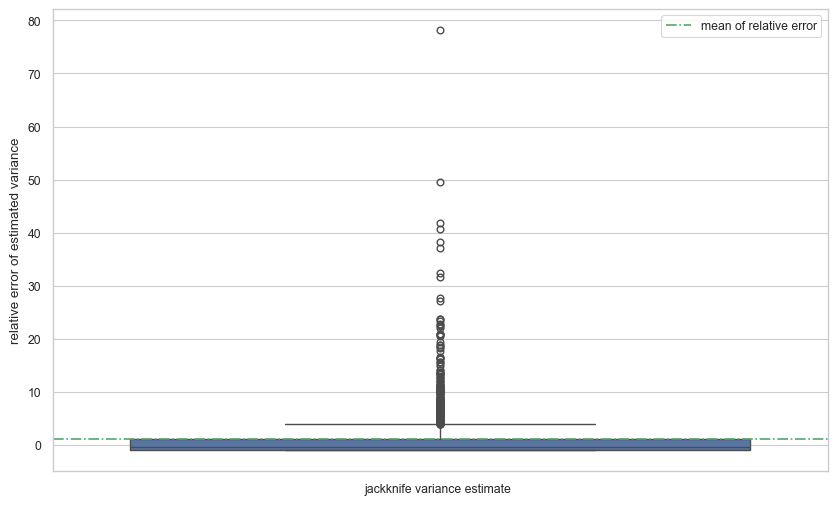

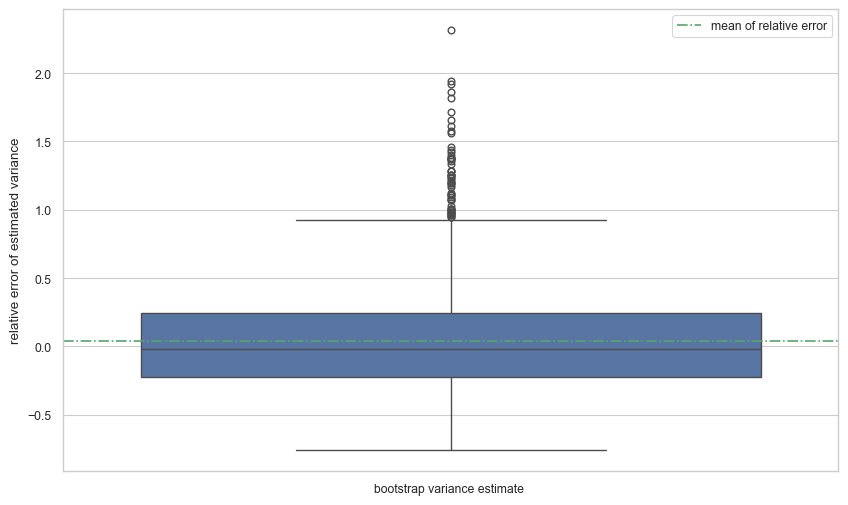

In [7]:
emp_var = np.var(var_emp)

# plot jackknife
df = pd.DataFrame({'jackknife variance estimate ': var_jackknife})
plt.figure(figsize=(10, 6))
sns.set_theme(context='paper',style="whitegrid") 
sns.boxplot(data=(df-emp_var)/emp_var) 
plt.axhline(y=np.mean((df-emp_var)/emp_var), color='g', linestyle='dashdot', label='mean of relative error')  
plt.ylabel('relative error of estimated variance')
plt.legend()
plt.savefig("boxplot_jk_non_linear_median.png", dpi = 1000)
plt.show()

# plot bootstrap
df = pd.DataFrame({'bootstrap variance estimate ': var_boot})
plt.figure(figsize=(10, 6))
sns.set_theme(context='paper',style="whitegrid") 
sns.boxplot(data=(df-emp_var)/emp_var) 
plt.axhline(y=np.mean((df-emp_var)/emp_var), color='g', linestyle='dashdot', label='mean of relative error')  
plt.ylabel('relative error of estimated variance')
plt.legend()
plt.savefig("boxplot_boot_non_linear_estimator_median.png", dpi = 1000)
plt.show()

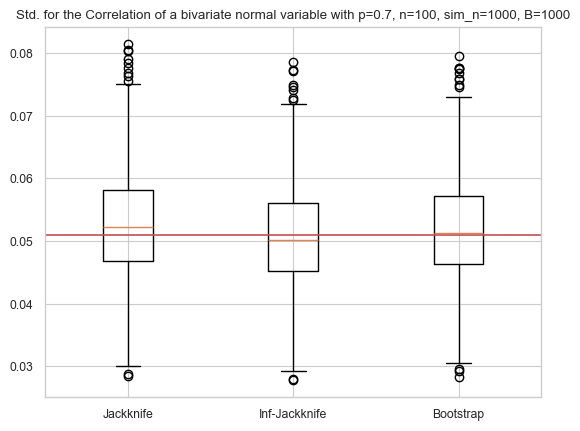

In [ ]:
# Definition der Funktionen
def jackknife(x,y, func):
    n = len(x)
    idx = np.arange(n)
    jack_i =  [func(x[idx!=i], y[idx!=i])[0,1] for i in range(n)]
    jack_mean = np.mean(jack_i)
    return np.sqrt(((n-1) / n )*np.sum((jack_i - jack_mean)**2))

def bootstrap(x, y, func, B):
    n = len(x)
    idxs = np.random.choice(np.arange(n), (B, n), replace=True)
    bootstrap = [func(x[idx], y[idx])[0,1] for idx in idxs]
    return np.std(bootstrap, ddof=1)

def mean_weighted(x,p_i):
    return np.sum(x*p_i)

def inf_jack(x,y,func,e):
    n = len(x)
    T_0 = func(x,y)[0,1]
    U_i = np.zeros(len(x))
    for i in range(n):
        weights_inf_jk  = np.full(n, (1 - e) / n)
        weights_inf_jk[i] += e
        mean_x = mean_weighted(x,weights_inf_jk)
        mean_y = mean_weighted(y,weights_inf_jk)
        T_weighted = np.sum(weights_inf_jk*(x-mean_x)*(y-mean_y)) /   np.sqrt( np.sum(weights_inf_jk*(x-mean_x)**2) * np.sum(weights_inf_jk*(y-mean_y)**2) )
        U_i[i] = (T_weighted - T_0 )/e
    return  np.sqrt(np.sum(U_i**2)/n**2)

### Simulation ###

# ZV´s
mean = [0, 0]          
p = 0.7     
cov = [[1,p], [p, 1]] 

sim_n = 1_000  # number of simulations
n = 100        # sample size
B = 1_000      # Bootstrap samples

se_jackknife = np.zeros(sim_n)
se_jackknife_inf = np.zeros(sim_n)
se_bootstrap = np.zeros(sim_n)

np.random.seed(42)
for i in range(sim_n):
    x, y = np.random.multivariate_normal(mean, cov, n).T
    
    se_jackknife[i] = jackknife(x,y, np.corrcoef)
    se_jackknife_inf[i] = inf_jack(x,y, np.corrcoef,0.000000001)
    se_bootstrap[i] = bootstrap(x,y, np.corrcoef,B)
    
# true std for the correlation https://www.jstor.org/stable/pdf/2277400.pdf?refreqid=fastly-default%3Aef46e66363b4ca95a1a81b2e1b6d92f0&ab_segments=&origin=&initiator=&acceptTC=1
true_sd_corr = (1-p**2)/np.sqrt(n)

# plot
plt.boxplot([se_jackknife, se_jackknife_inf, se_bootstrap], labels=['Jackknife','Inf-Jackknife', 'Bootstrap'])
plt.axhline(y=true_sd_corr, color='r', linestyle='-')
plt.title(f'Std. for the Correlation of a bivariate normal variable with p={p}, n={n}, sim_n={sim_n}, B={B}')
plt.savefig(
        "boxplot_JK_nonlinear_estimator.png"
    )
#true_sd_corr